In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBClassifier
from bayes_opt import BayesianOptimization
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE,ADASYN,BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
import os
import joblib
import shap

In [4]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent

In [5]:
df = pd.read_csv(Path(project_root, "data","scoring_data", "credit_risk_dataset.csv"))

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [9]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [10]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

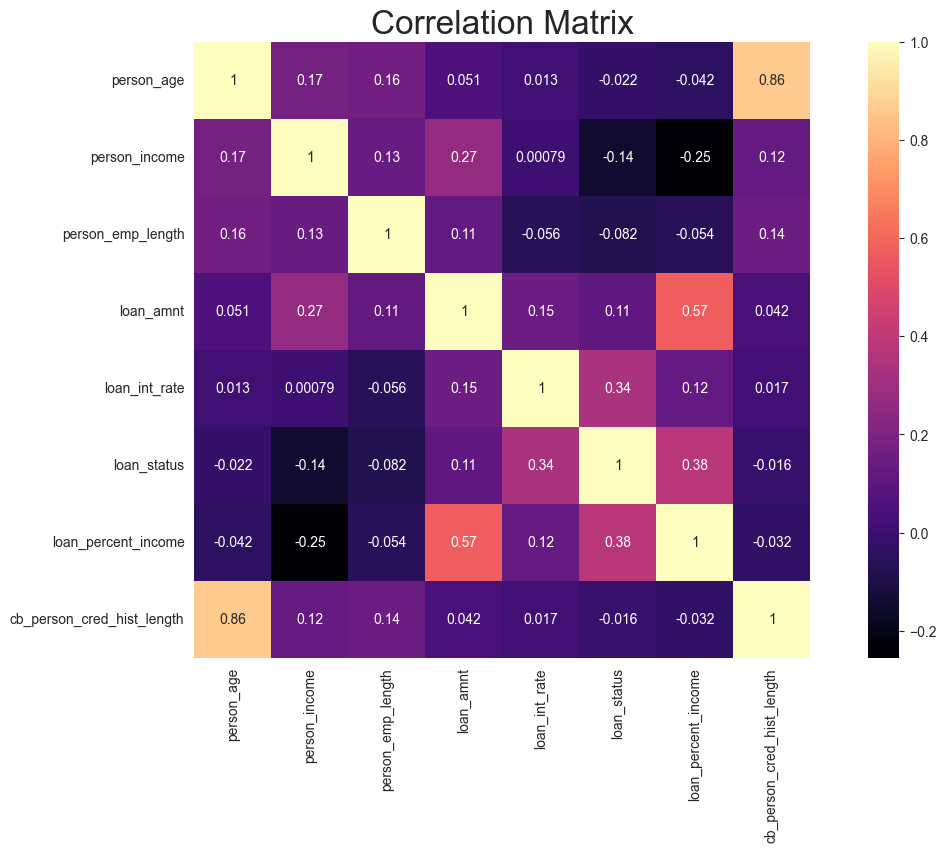

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(15,8)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="magma", square=True)
plt.title("Correlation Matrix", fontsize=24)

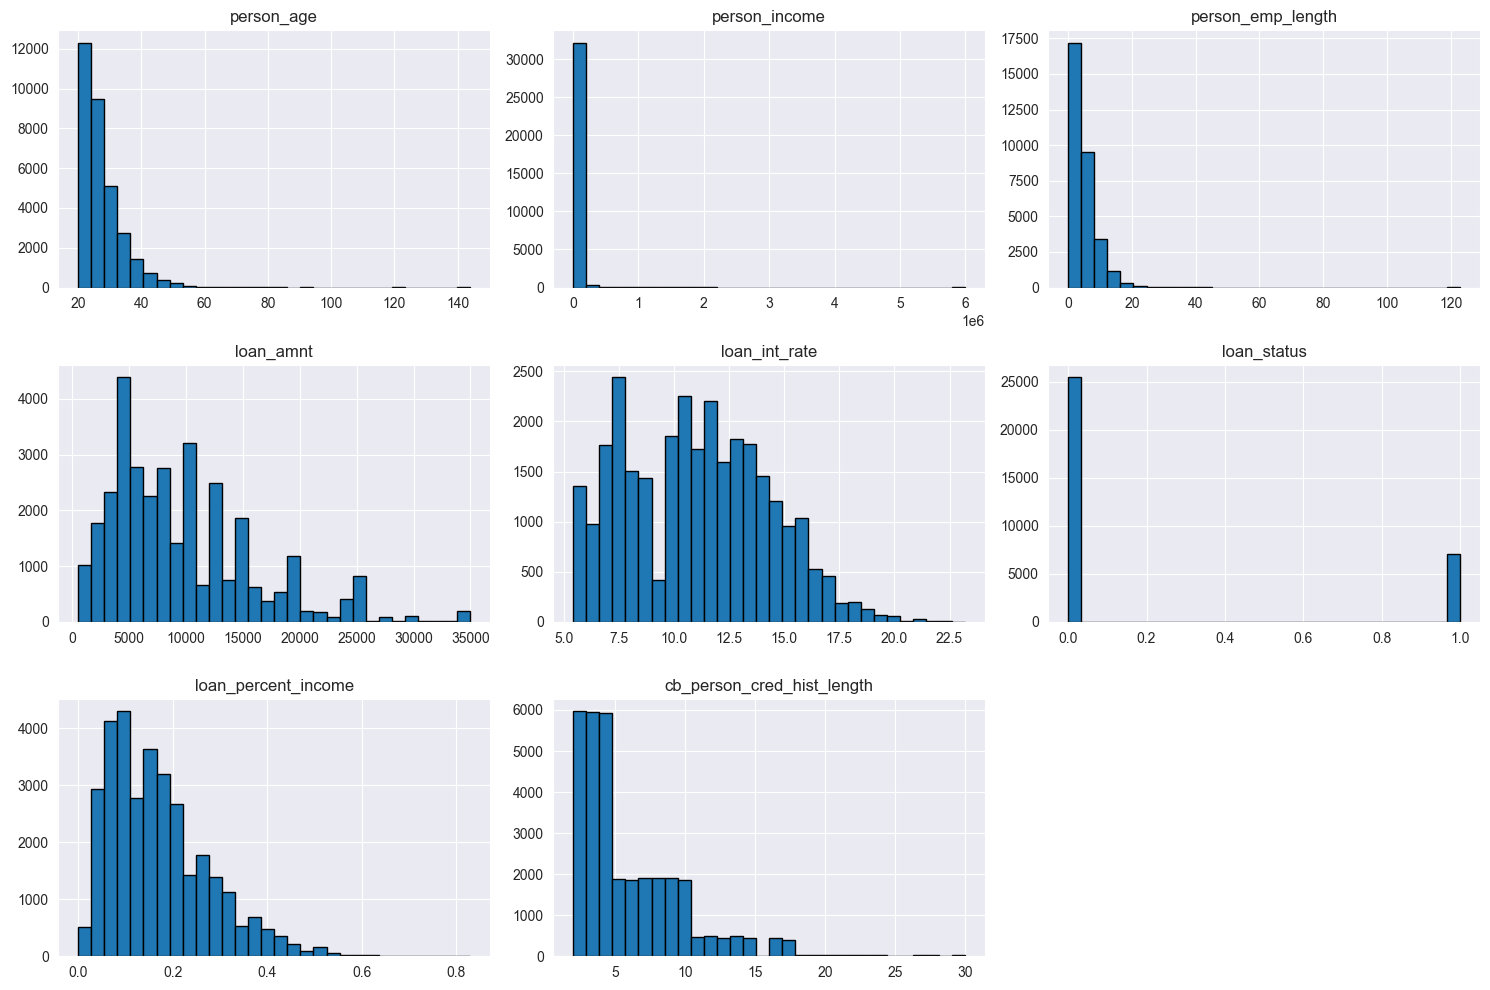

In [12]:
df.hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black",
)
plt.tight_layout()
plt.show()

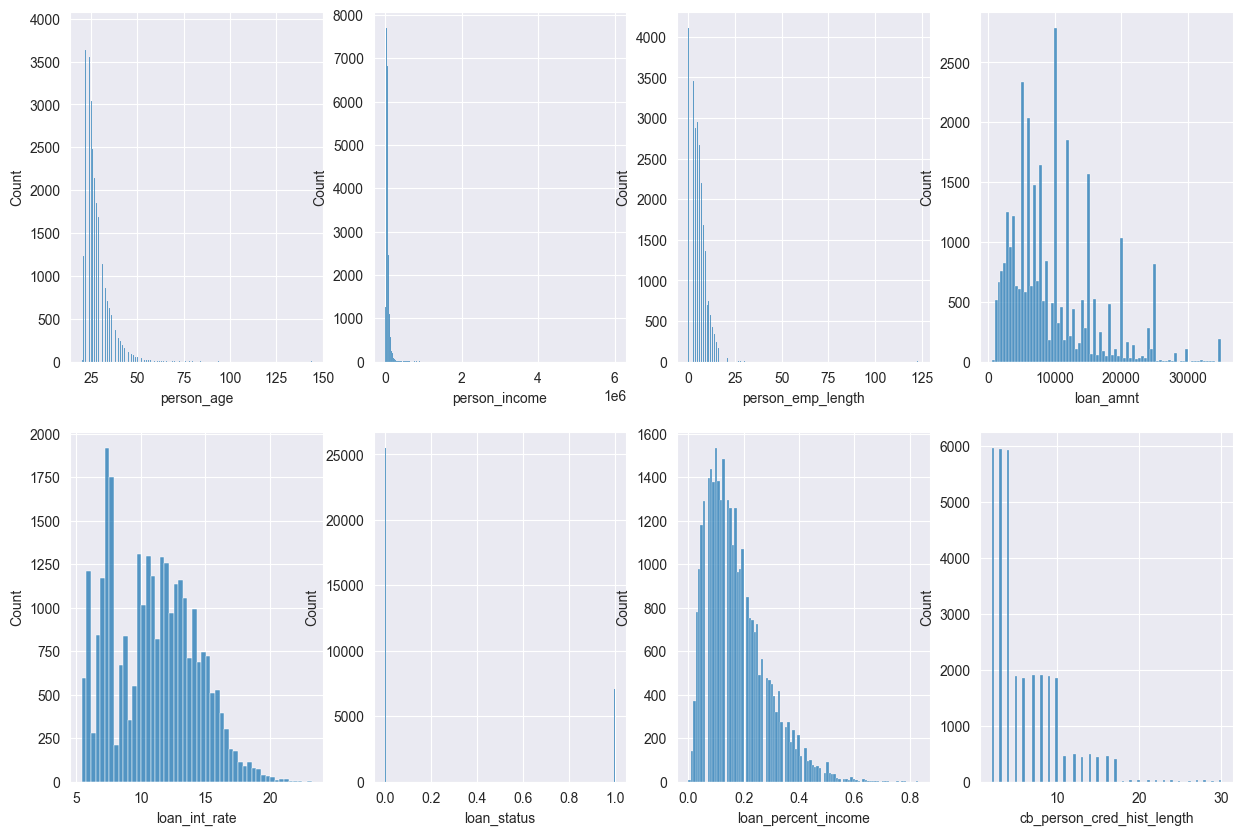

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=4,figsize=(15,10))

for i,col in enumerate(df.select_dtypes(include="number").columns):
    sns.histplot(df[col], ax=axes[i//4,i%4])

In [14]:
df[df["person_age"]>80].person_age.value_counts()

person_age
144    3
123    2
94     1
84     1
Name: count, dtype: int64

In [15]:
df = df.drop(df[df["person_age"]>80].index, axis=0)

In [16]:
df[df["person_emp_length"]>40].person_emp_length.value_counts()

person_emp_length
123.0    2
41.0     1
Name: count, dtype: int64

In [17]:
df = df.drop(df[df["person_emp_length"]>50].index, axis=0)

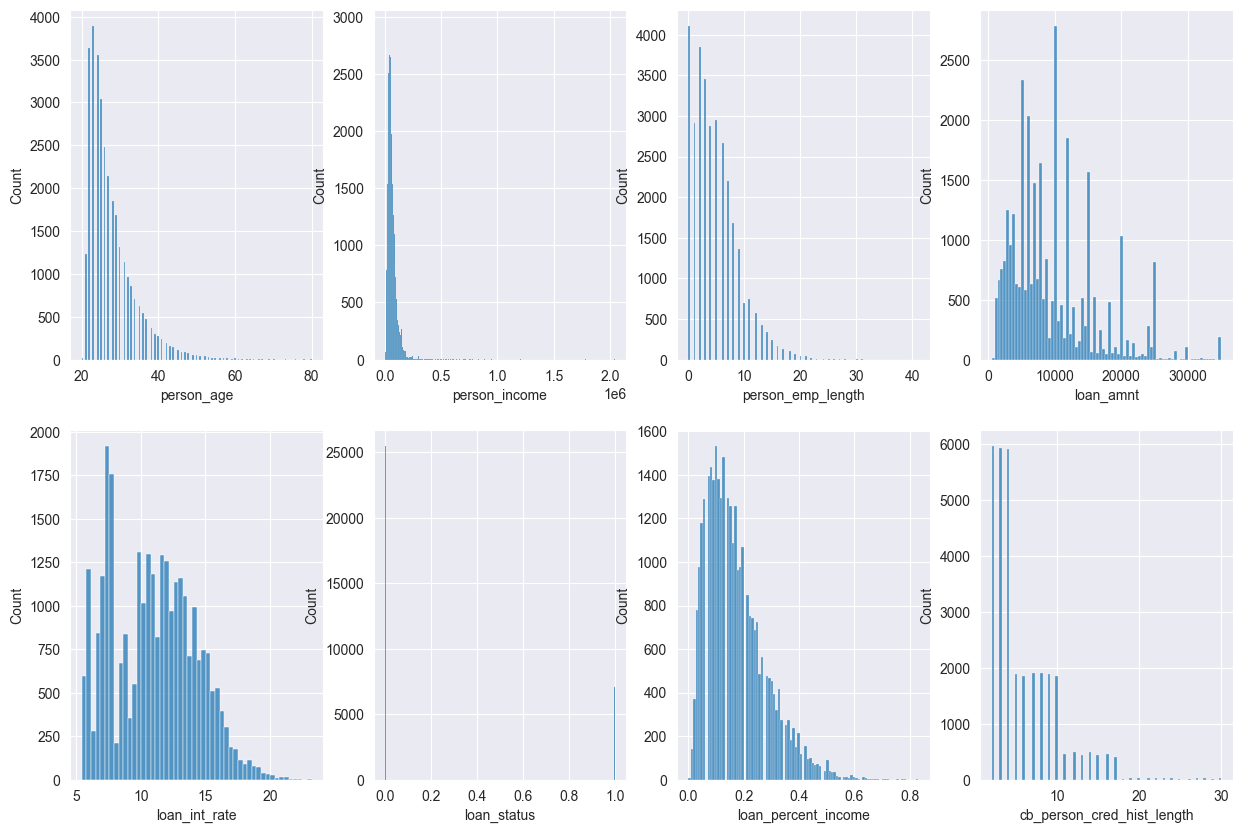

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=4,figsize=(15,10))

for i,col in enumerate(df.select_dtypes(include="number").columns):
    sns.histplot(df[col], ax=axes[i//4,i%4])

In [19]:
df.person_income.value_counts().sort_index(ascending=False).head(10)

person_income
2039784    1
1900000    1
1782000    1
1440000    1
1362000    1
1200000    3
948000     1
900000     4
889000     1
828000     2
Name: count, dtype: int64

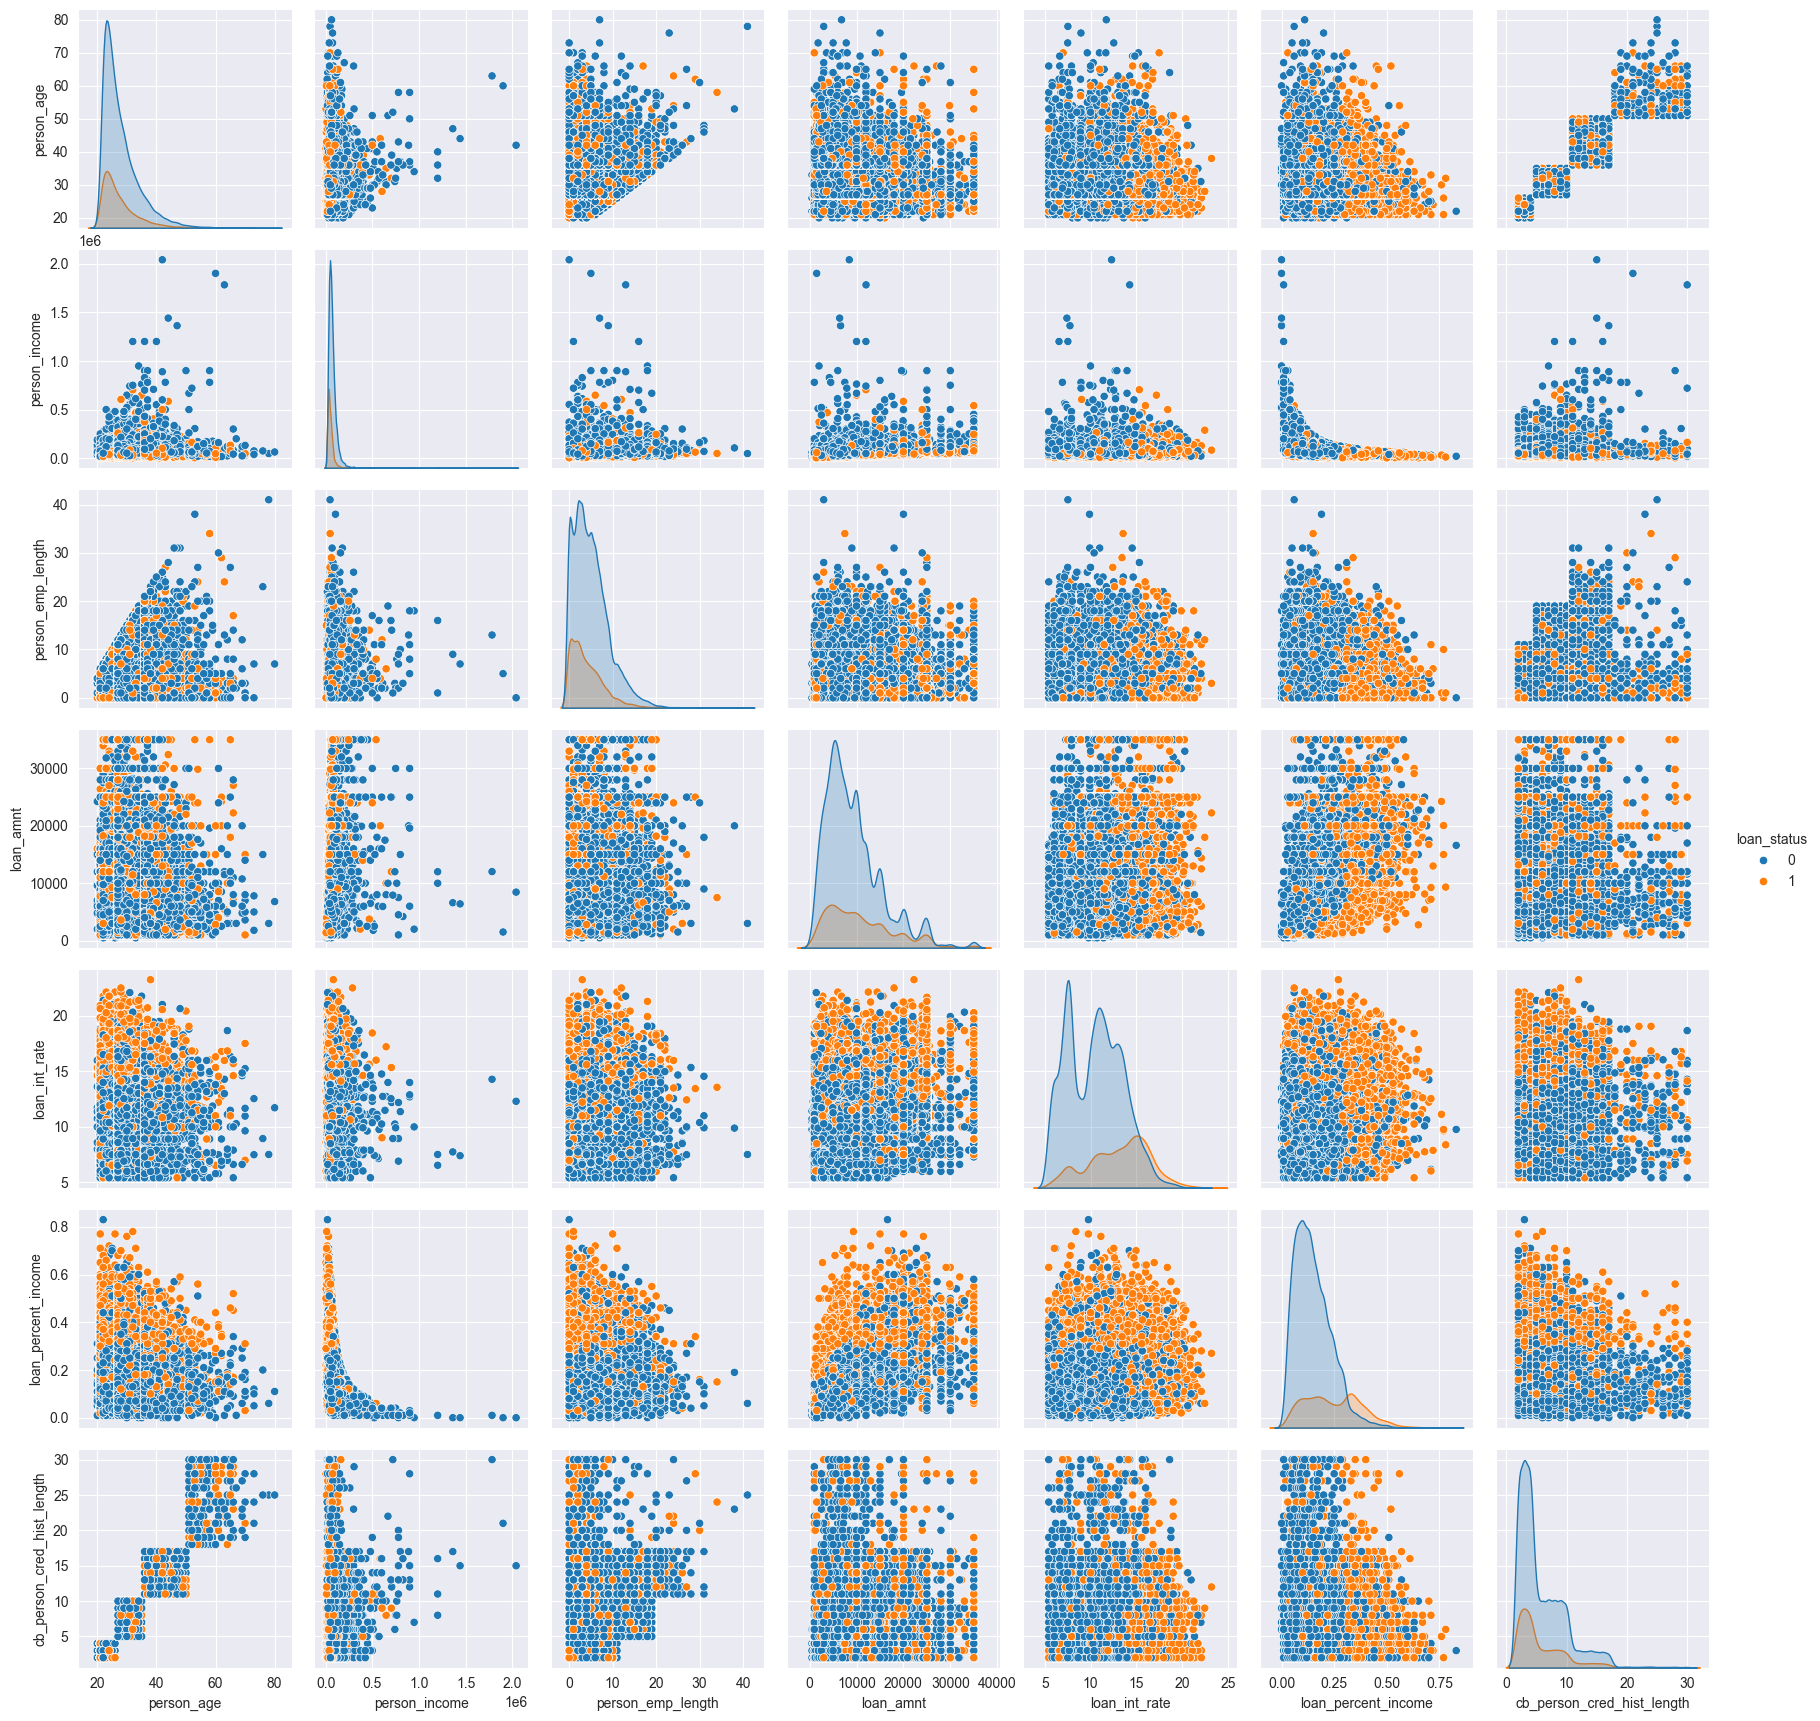

In [20]:
sns.pairplot(df, hue="loan_status")
plt.show()

In [21]:
df["loan_status"].value_counts()

loan_status
0    25465
1     7107
Name: count, dtype: int64

In [22]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3114
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

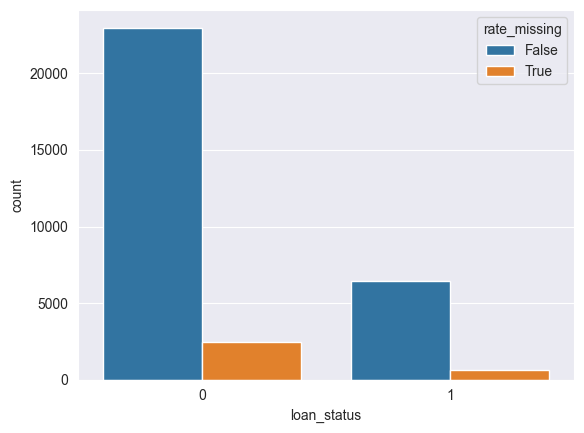

In [23]:
df["rate_missing"] = df["loan_int_rate"].isna()

sns.countplot(
    data=df,
    x="loan_status",
    hue="rate_missing"
)

plt.show()

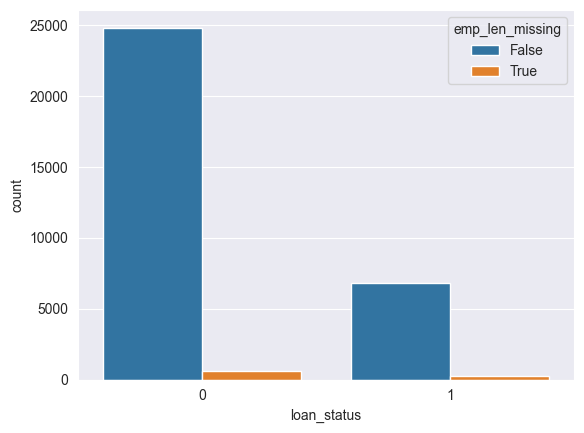

In [24]:
df["emp_len_missing"] = df["person_emp_length"].isna()

sns.countplot(
    data=df,
    x="loan_status",
    hue="emp_len_missing"
)

plt.show()

In [25]:
df[df["rate_missing"]==True]["loan_status"].value_counts()

loan_status
0    2470
1     644
Name: count, dtype: int64

In [26]:
df[df["rate_missing"]==False]["loan_status"].value_counts()

loan_status
0    22995
1     6463
Name: count, dtype: int64

In [27]:
df[df["emp_len_missing"]==True]["loan_status"].value_counts()

loan_status
0    613
1    282
Name: count, dtype: int64

In [28]:
df[df["emp_len_missing"]==False]["loan_status"].value_counts()

loan_status
0    24852
1     6825
Name: count, dtype: int64

In [29]:
df["rate_missing"] = df["rate_missing"].astype(int)
df["emp_len_missing"] = df["emp_len_missing"].astype(int)

In [30]:
df_clean = df.dropna(subset=["person_emp_length"])

In [31]:
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(df_clean["loan_int_rate"].mean())

In [32]:
df_clean.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
rate_missing                  0
emp_len_missing               0
dtype: int64

In [33]:
df_clean["age_group"] = pd.cut(df_clean["person_age"],
       bins=[0,20,26,36,46,56,66,float("inf")],
       labels=["0-19", "20-25", "26-35", "36-45", "46-55", "56-65","66-"])

In [34]:
df_clean['age_group'].dtype

CategoricalDtype(categories=['0-19', '20-25', '26-35', '36-45', '46-55', '56-65', '66-'], ordered=True, categories_dtype=str)

In [35]:
df_clean["income_group"] = pd.cut(df_clean["person_income"],
                                  bins=[0, 25000, 50000, 75000, 100000, float("inf")],
                                  labels=["low", "low-middle", "middle", "high-middle", "high"])


In [36]:
df_clean["income_group"]

1                low
2                low
3             middle
4             middle
5                low
            ...     
32576         middle
32577           high
32578    high-middle
32579           high
32580     low-middle
Name: income_group, Length: 31677, dtype: category
Categories (5, str): ['low' < 'low-middle' < 'middle' < 'high-middle' < 'high']

In [37]:
df_clean["loan_amount_group"] = pd.cut(df_clean["loan_amnt"],
                                       bins=[0,5000,10000,15000,float("inf")],
                                       labels=["small", "medium", "large", "very-large"])

In [38]:
df_clean.dtypes

person_age                       int64
person_income                    int64
person_home_ownership              str
person_emp_length              float64
loan_intent                        str
loan_grade                         str
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file          str
cb_person_cred_hist_length       int64
rate_missing                     int64
emp_len_missing                  int64
age_group                     category
income_group                  category
loan_amount_group             category
dtype: object

In [86]:
df_clean['loan_to_emp_length_ratio'] =  df_clean['person_emp_length']/ df_clean['loan_amnt']

df_clean['int_rate_to_loan_amt_ratio'] = df_clean['loan_int_rate'] / df_clean['loan_amnt']

df_clean['loan_to_income_ratio'] = df_clean['loan_amnt'] / df_clean['person_income']

In [87]:
df_clean.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'rate_missing', 'emp_len_missing', 'age_group', 'income_group',
       'loan_amount_group', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio', 'loan_to_income_ratio'],
      dtype='str')

In [88]:
df_clean.dtypes

person_age                       int64
person_income                    int64
person_home_ownership              str
person_emp_length              float64
loan_intent                        str
loan_grade                         str
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file          str
cb_person_cred_hist_length       int64
rate_missing                     int64
emp_len_missing                  int64
age_group                     category
income_group                  category
loan_amount_group             category
loan_to_emp_length_ratio       float64
int_rate_to_loan_amt_ratio     float64
loan_to_income_ratio           float64
dtype: object

In [89]:
X = df_clean.drop(["loan_status"], axis=1)
y = df_clean["loan_status"]

In [90]:
scale_cols = X.select_dtypes(include="number").columns.tolist()

In [91]:
ohe_columns = X.columns[~X.columns.isin(scale_cols)].tolist()

In [92]:
for col in ohe_columns:
    print(X[col].unique())

<ArrowStringArray>
['OWN', 'MORTGAGE', 'RENT', 'OTHER']
Length: 4, dtype: str
<ArrowStringArray>
[        'EDUCATION',           'MEDICAL',           'VENTURE',
          'PERSONAL',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
<ArrowStringArray>
['B', 'C', 'A', 'D', 'E', 'F', 'G']
Length: 7, dtype: str
<ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
['20-25', '0-19', '26-35', '36-45', '46-55', '56-65', '66-']
Categories (7, str): ['0-19' < '20-25' < '26-35' < '36-45' < '46-55' < '56-65' < '66-']
['low', 'middle', 'high-middle', 'high', 'low-middle']
Categories (5, str): ['low' < 'low-middle' < 'middle' < 'high-middle' < 'high']
['small', 'medium', 'very-large', 'large']
Categories (4, str): ['small' < 'medium' < 'large' < 'very-large']


In [93]:
x_train, x_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=12, stratify=y)

In [94]:
print(x_train.shape, x_test.shape)

(25341, 19) (6336, 19)


In [95]:
x_train.groupby("age_group")["cb_person_cred_hist_length"].value_counts(normalize=True)

age_group  cb_person_cred_hist_length
0-19       2                             0.500000
           4                             0.400000
           3                             0.100000
20-25      2                             0.335710
           3                             0.334630
                                           ...   
66-        27                            0.133333
           28                            0.133333
           20                            0.066667
           26                            0.066667
           23                            0.066667
Name: proportion, Length: 67, dtype: float64

In [96]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=True), ohe_columns),
        ("num", StandardScaler(), scale_cols),
    ],
    remainder="passthrough"
)

In [97]:
x_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'rate_missing', 'emp_len_missing',
       'age_group', 'income_group', 'loan_amount_group',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio',
       'loan_to_income_ratio'],
      dtype='str')

In [98]:
(x_train["cb_person_cred_hist_length"].max()
     ,x_train["cb_person_cred_hist_length"].mean(),
 x_train["cb_person_cred_hist_length"].min(),)

(np.int64(30), np.float64(5.809163016455546), np.int64(2))

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

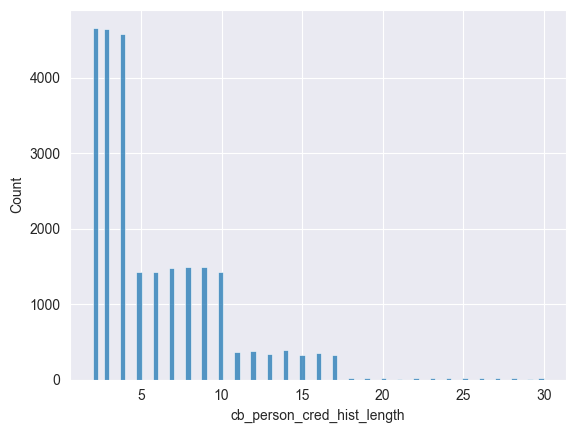

In [99]:
sns.histplot(x_train["cb_person_cred_hist_length"])

In [100]:
x_train["cb_person_cred_hist_length"].value_counts().sort_index(ascending=False)

cb_person_cred_hist_length
30      18
29      11
28      18
27      17
26      16
25      16
24      24
23      16
22      17
21      13
20      26
19      17
18      15
17     331
16     352
15     323
14     397
13     337
12     378
11     371
10    1428
9     1489
8     1487
7     1478
6     1428
5     1424
4     4581
3     4647
2     4666
Name: count, dtype: int64

In [101]:
(x_train["loan_int_rate"].max()
     ,x_train["loan_int_rate"].mean(),
 x_train["loan_int_rate"].min(),)

(np.float64(22.11), np.float64(11.038112347158645), np.float64(5.42))

<Axes: xlabel='loan_int_rate', ylabel='Count'>

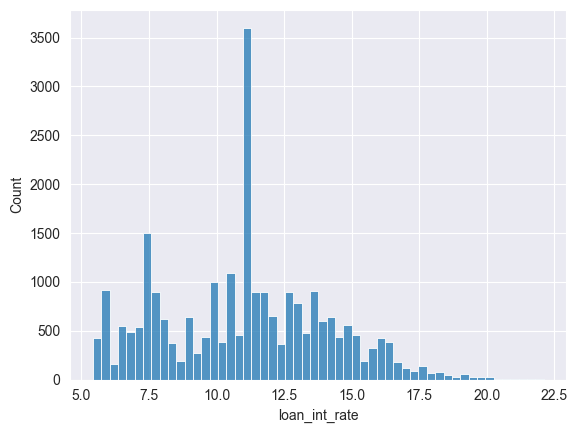

In [102]:
sns.histplot(x_train["loan_int_rate"])

In [103]:
x_train["loan_grade"].value_counts()

loan_grade
A    8280
B    8201
C    5027
D    2813
E     770
F     196
G      54
Name: count, dtype: int64

In [104]:
scale_cols

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'rate_missing',
 'emp_len_missing',
 'loan_to_emp_length_ratio',
 'int_rate_to_loan_amt_ratio',
 'loan_to_income_ratio']

In [105]:
x_train_processed = preprocess.fit_transform(x_train)

In [106]:
type(x_train_processed)

numpy.ndarray

In [107]:
x_train_processed

array([[ 1.        ,  0.        ,  0.        , ..., -0.60346682,
        -0.8990722 , -0.57418824],
       [ 0.        ,  0.        ,  0.        , ..., -0.53866376,
        -0.04798512, -0.83119506],
       [ 0.        ,  0.        ,  1.        , ..., -0.24704997,
         0.47436086,  1.01522383],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.5797057 ,
         0.09155238,  0.54093709],
       [ 1.        ,  0.        ,  0.        , ..., -0.29241212,
        -0.77435193, -0.34123624],
       [ 1.        ,  0.        ,  0.        , ..., -0.33484767,
        -0.68672511,  1.57096416]], shape=(25341, 47))

In [108]:
train_df = pd.DataFrame(
    x_train_processed,
    columns=preprocess.get_feature_names_out()
)

In [109]:
x_test_processed = preprocess.transform(x_test)

In [110]:
test_df = pd.DataFrame(
    x_test_processed,
    columns=preprocess.get_feature_names_out()
)

In [111]:
hist_cols = X.select_dtypes(include="number")

In [67]:
hist_cols = hist_cols.columns.map(lambda x: "num__"+x)

In [68]:
hist_cols

Index(['num__person_age', 'num__person_income', 'num__person_emp_length',
       'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income',
       'num__cb_person_cred_hist_length', 'num__rate_missing',
       'num__emp_len_missing', 'num__loan_to_emp_length_ratio',
       'num__int_rate_to_loan_amt_ratio'],
      dtype='str')

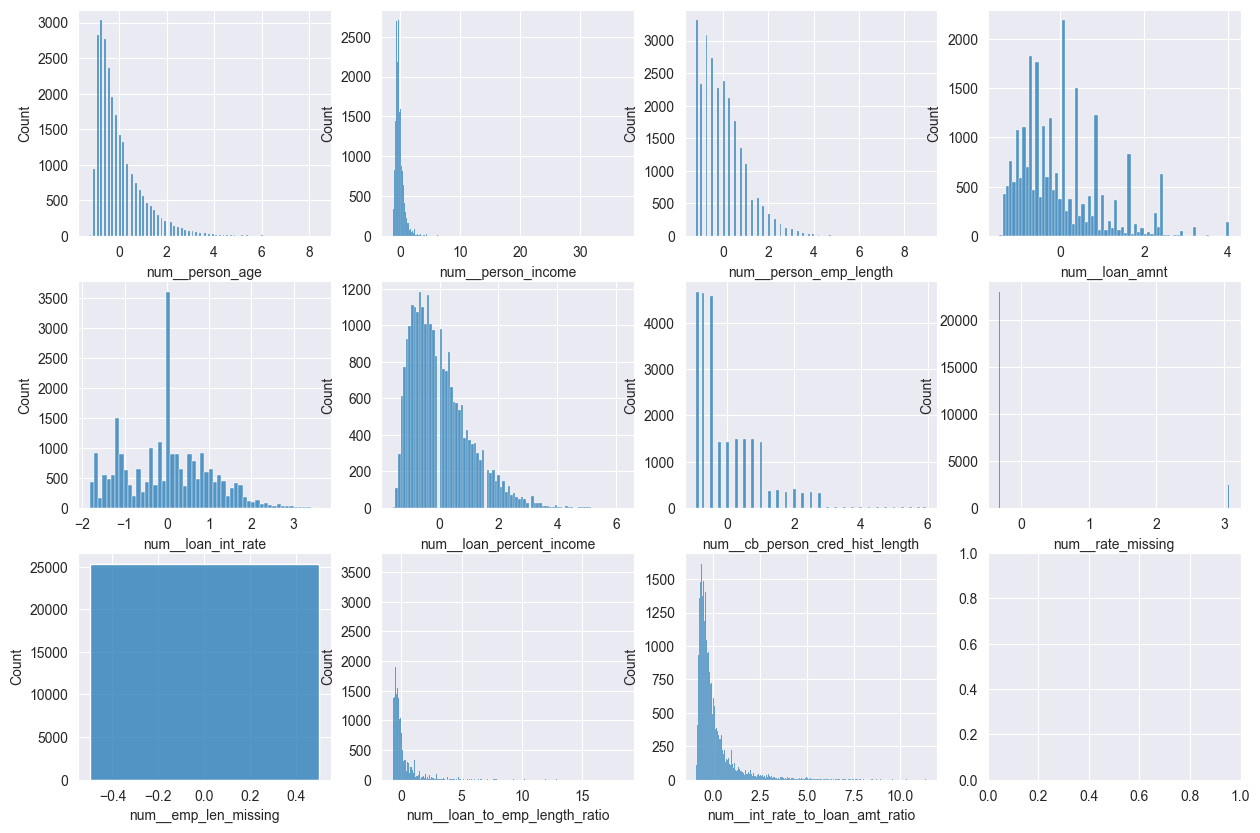

In [69]:
fig, axes = plt.subplots(nrows=3, ncols=4,figsize=(15,10))

for i,col in enumerate(hist_cols):
    sns.histplot(train_df[col], ax=axes[i//4,i%4])

In [70]:
def xgboost_clf_bo(n_estimators,max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, gamma):
    params_xgb = {"objective":"binary:logistic"}
    params_xgb["max_depth"]=round(max_depth)
    params_xgb["min_child_weight"]=min_child_weight
    params_xgb["subsample"]=subsample
    params_xgb["colsample_bytree"]=colsample_bytree
    params_xgb["learning_rate"]=learning_rate
    params_xgb["gamma"]=gamma
    params_xgb["n_estimators"] = round(n_estimators)

    scores = cross_val_score(XGBClassifier(random_state=12, **params_xgb), train_df, y_train, cv=10, scoring="f1").mean()
    return scores


In [71]:
params_xgb = {
    "max_depth":(3,15),
    "learning_rate":(0.005, 0.3),
    "min_child_weight":(1e-6, 1e-1),
    "subsample":(0.5, 1),
    "colsample_bytree":(0.5, 1),
    "gamma":(0,5),
    "n_estimators":(100,2000)
}

In [72]:
train_df.columns

Index(['cat__person_home_ownership_MORTGAGE',
       'cat__person_home_ownership_OTHER', 'cat__person_home_ownership_OWN',
       'cat__person_home_ownership_RENT', 'cat__loan_intent_DEBTCONSOLIDATION',
       'cat__loan_intent_EDUCATION', 'cat__loan_intent_HOMEIMPROVEMENT',
       'cat__loan_intent_MEDICAL', 'cat__loan_intent_PERSONAL',
       'cat__loan_intent_VENTURE', 'cat__loan_grade_A', 'cat__loan_grade_B',
       'cat__loan_grade_C', 'cat__loan_grade_D', 'cat__loan_grade_E',
       'cat__loan_grade_F', 'cat__loan_grade_G',
       'cat__cb_person_default_on_file_N', 'cat__cb_person_default_on_file_Y',
       'cat__age_group_0-19', 'cat__age_group_20-25', 'cat__age_group_26-35',
       'cat__age_group_36-45', 'cat__age_group_46-55', 'cat__age_group_56-65',
       'cat__age_group_66-', 'cat__income_group_high',
       'cat__income_group_high-middle', 'cat__income_group_low',
       'cat__income_group_low-middle', 'cat__income_group_middle',
       'cat__loan_amount_group_large', 'c

In [132]:
xgb_bo = BayesianOptimization(xgboost_clf_bo, params_xgb)
xgb_bo.maximize(init_points=2, n_iter=20)

|   iter    |  target   | max_depth | learni... | min_ch... | subsample | colsam... |   gamma   | n_esti... |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.8251478 | 5.9253617 | 0.2187662 | 0.0106461 | 0.6529365 | 0.6587754 | 4.4174663 | 284.23605 |
| 2         | 0.8291410 | 8.2716619 | 0.0318789 | 0.0786669 | 0.8165676 | 0.9408318 | 3.3531629 | 559.71003 |
| 3         | 0.8300618 | 7.3391077 | 0.0520444 | 0.0624265 | 0.6810005 | 0.8606817 | 2.6867152 | 559.09172 |
| 4         | 0.8316037 | 4.4720574 | 0.1388512 | 0.0146025 | 0.5       | 0.5951264 | 0.1814722 | 555.96141 |
| 5         | 0.8265678 | 3.8339782 | 0.0445310 | 0.0709282 | 0.5819633 | 0.5932809 | 3.4205454 | 548.18548 |
| 6         | 0.8253826 | 3.0       | 0.3       | 1e-06     | 0.5       | 0.5       | 0.0       | 561.09614 |
| 7         | 0.8334043 | 6.9247287 | 0.0329666 | 0.0357528 | 0.5595690 | 0.7998135 | 1.2934350 | 555.51340 |
| 8       

In [133]:
params = xgb_bo.max["params"]

In [134]:
params["n_estimators"] = round(params["n_estimators"])
params["max_depth"] = round(params["max_depth"])


In [135]:
xgb = XGBClassifier(**params, random_state=12)

In [79]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm)
    tn,tp,fn,fp = cm.ravel()
    specificity = tn / (tn + fp)

    f1 = 2*precision*recall/(precision+recall)

    return clf, accuracy, precision, recall, specificity, f1


In [139]:
model, accuracy, precision, recall, specificity, f1 = train_classifier(xgb, train_df, y_train, x_test_processed, y_test)

In [140]:
accuracy, precision, recall, specificity, f1

(0.9373421717171717,
 0.935251798561151,
 0.7619047619047619,
 np.float64(0.8248863445024415),
 0.8397254743641501)

In [141]:
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.5)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [95]:
model, accuracy, precision, recall, specificity, f1 = train_classifier(XGBClassifier(random_state=12), train_df, y_train, x_test_processed, y_test)

In [69]:
accuracy, precision, recall, specificity, f1

(0.9329229797979798,
 0.9611273080660836,
 0.7197962154294032,
 np.float64(0.8326848249027238),
 0.823137744486059)

In [96]:
y_train

17924    0
6002     0
199      1
5024     0
14779    0
        ..
27244    0
4276     0
26105    0
15630    0
3457     0
Name: loan_status, Length: 25341, dtype: int64

<Axes: xlabel='loan_status', ylabel='Count'>

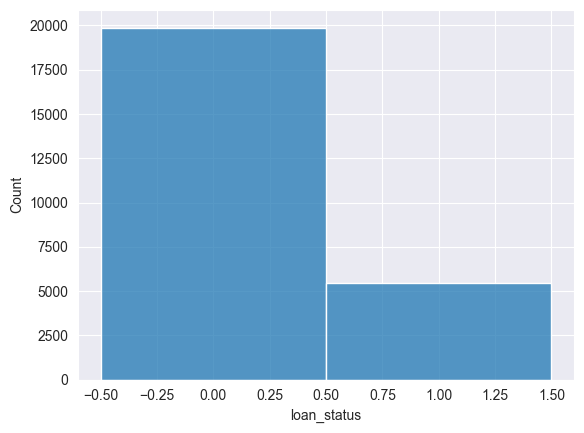

In [98]:
sns.histplot(y_train, discrete=True)

In [120]:
smote = SMOTEENN(sampling_strategy=0.8, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(train_df,y_train)

<Axes: xlabel='loan_status', ylabel='Count'>

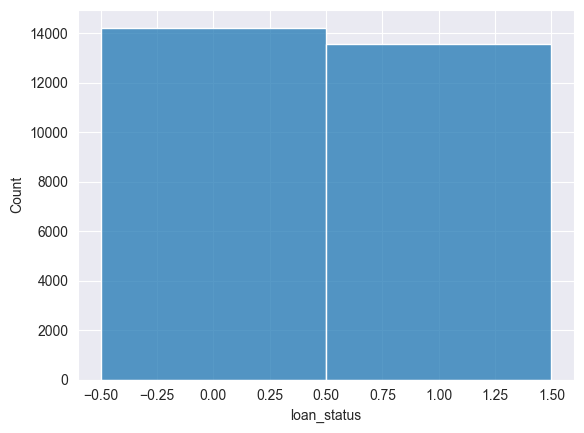

In [121]:
sns.histplot(y_train_sm,discrete=True)

In [122]:
y_train_sm.value_counts()

loan_status
0    14237
1    13588
Name: count, dtype: int64

In [123]:
def xgboost_clf_bo_balanced(n_estimators,max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, gamma):
    params_xgb = {"objective":"binary:logistic"}
    params_xgb["max_depth"]=round(max_depth)
    params_xgb["min_child_weight"]=min_child_weight
    params_xgb["subsample"]=subsample
    params_xgb["colsample_bytree"]=colsample_bytree
    params_xgb["learning_rate"]=learning_rate
    params_xgb["gamma"]=gamma
    params_xgb["n_estimators"] = round(n_estimators)

    scores = cross_val_score(XGBClassifier(random_state=12, **params_xgb), X_train_sm, y_train_sm, cv=10, scoring="f1").mean()
    return scores


In [124]:
params_xgb = {
    "max_depth":(3,15),
    "learning_rate":(0.005, 0.3),
    "min_child_weight":(1e-6, 1e-1),
    "subsample":(0.5, 1),
    "colsample_bytree":(0.5, 1),
    "gamma":(0,5),
    "n_estimators":(100,2000)
}

In [125]:
xgb_bo_bld = BayesianOptimization(xgboost_clf_bo_balanced, params_xgb)
xgb_bo_bld.maximize(init_points=2, n_iter=20)

|   iter    |  target   | max_depth | learni... | min_ch... | subsample | colsam... |   gamma   | n_esti... |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.9685440 | 13.234443 | 0.0479338 | 0.0211024 | 0.5074214 | 0.8036458 | 4.1205674 | 1900.1519 |
| 2         | 0.9669429 | 13.735821 | 0.0469361 | 0.0134577 | 0.8366361 | 0.8566994 | 4.5458175 | 1346.1990 |
| 3         | 0.9680372 | 12.797250 | 0.1902032 | 0.0555597 | 0.7584084 | 0.7286052 | 4.3572779 | 1898.9695 |
| 4         | 0.9708843 | 14.422933 | 0.0593314 | 0.0128050 | 0.5991192 | 0.7526823 | 3.3163829 | 1901.9034 |
| 5         | 0.9720048 | 15.0      | 0.0390869 | 0.0057038 | 0.6453398 | 0.7654188 | 2.6694214 | 1903.7083 |
| 6         | 0.9641912 | 15.0      | 0.3       | 0.0869770 | 0.9950638 | 0.5       | 5.0       | 1907.6567 |
| 7         | 0.9769506 | 15.0      | 0.005     | 1e-06     | 0.5       | 0.9518682 | 0.0       | 1902.8064 |
| 8       

In [126]:
params_balanced = xgb_bo_bld.max["params"]
params_balanced["n_estimators"] = round(params_balanced["n_estimators"])
params_balanced["max_depth"] = round(params_balanced["max_depth"])

xgb_balanced = XGBClassifier(**params_balanced, random_state=12)

In [127]:
model_balanced, accuracy_balanced, precision_balanced, recall_balanced, specificity_balanced, f1_balanced = train_classifier(xgb_balanced,
                                                                                                                             X_train_sm,
                                                                                                                             y_train_sm,
                                                                                                                             x_test_processed,
                                                                                                                             y_test)

In [128]:
model_balanced, accuracy_balanced, precision_balanced, recall_balanced, specificity_balanced, f1_balanced

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=np.float64(0.5715566281854959), device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=np.float64(0.0), grow_policy=None, importance_type=None,
               interaction_constraints=None,
               learning_rate=np.float64(0.06257760019331712), max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=15, max_leaves=None,
               min_child_weight=np.float64(1e-06), missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1933,
               n_jobs=None, num_parallel_tree=None, ...),
 0.9086174242424242,
 0.8018433179723502,
 0.7648351648351648,
 np.float64(0.8186555497655029),
 0.782902137232846)

In [58]:
def xgboost_clf_bo_weighted(n_estimators,max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, gamma, scale_pos_weight):
    params_xgb = {"objective":"binary:logistic"}
    params_xgb["max_depth"]=round(max_depth)
    params_xgb["min_child_weight"]=min_child_weight
    params_xgb["subsample"]=subsample
    params_xgb["colsample_bytree"]=colsample_bytree
    params_xgb["learning_rate"]=learning_rate
    params_xgb["gamma"]=gamma
    params_xgb["n_estimators"] = round(n_estimators)
    params_xgb["scale_pos_weight"] = scale_pos_weight

    scores = cross_val_score(XGBClassifier(random_state=12, **params_xgb), train_df, y_train, cv=10, scoring="f1").mean()
    return scores


In [59]:
neg_class = y_train.value_counts()[0]
pos_class = y_train.value_counts()[1]
scale_pos_weight = neg_class / pos_class

In [60]:
params_xgb = {
    "max_depth":(3,15),
    "learning_rate":(0.005, 0.3),
    "min_child_weight":(1e-6, 1e-1),
    "subsample":(0.5, 1),
    "colsample_bytree":(0.5, 1),
    "gamma":(0,5),
    "n_estimators":(100,2000),
    "scale_pos_weight":(scale_pos_weight-1,scale_pos_weight+1)
}

In [61]:
xgb_bo_weighted = BayesianOptimization(xgboost_clf_bo_weighted, params_xgb)
xgb_bo_weighted.maximize(init_points=2, n_iter=20)
params_weighted = xgb_bo_weighted.max["params"]
params_weighted["n_estimators"] = round(params_weighted["n_estimators"])
params_weighted["max_depth"] = round(params_weighted["max_depth"])

xgb_weighted= XGBClassifier(**params_weighted, random_state=12)

|   iter    |  target   | max_depth | learni... | min_ch... | subsample | colsam... |   gamma   | n_esti... | scale_... |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 0.8140599 | 3.0662702 | 0.2429946 | 0.0445687 | 0.9353097 | 0.8613256 | 1.1900308 | 1554.8936 | 3.3488559 |
| 2         | 0.8099728 | 11.497241 | 0.0128546 | 0.0898279 | 0.6440571 | 0.9856893 | 3.9862812 | 334.89529 | 3.7750926 |
| 3         | 0.8257950 | 3.9290206 | 0.2292815 | 0.0688908 | 0.8502381 | 0.7450380 | 1.5804434 | 1555.7142 | 2.9867077 |
| 4         | 0.8377560 | 11.991646 | 0.1536777 | 0.0384379 | 0.8788613 | 0.5030329 | 0.1173029 | 781.82177 | 3.4479015 |
| 5         | 0.8160711 | 6.9222190 | 0.1729215 | 0.0563119 | 0.5213011 | 0.7513128 | 4.1223266 | 1860.5533 | 2.9131000 |
| 6         | 0.8239452 | 14.903481 | 0.2824429 | 0.0013522 | 0.9804870 | 0.7807917 | 0.7878362 | 306.43538 | 3.6913291 |
| 7         | 0.8218173 

In [64]:
model_weighted, accuracy_weighted, precision_weighted, recall_weighted, specificity_weighted, f1_weighted = train_classifier(xgb_weighted, x_train_processed, y_train,x_test_processed,y_test)

In [66]:
accuracy_weighted, precision_weighted, recall_weighted, specificity_weighted, f1_weighted

(0.9370265151515151,
 0.9297153024911032,
 0.7655677655677655,
 np.float64(0.8239851776991747),
 0.8396946564885497)

In [67]:
train_df.columns

Index(['cat__person_home_ownership_MORTGAGE',
       'cat__person_home_ownership_OTHER', 'cat__person_home_ownership_OWN',
       'cat__person_home_ownership_RENT', 'cat__loan_intent_DEBTCONSOLIDATION',
       'cat__loan_intent_EDUCATION', 'cat__loan_intent_HOMEIMPROVEMENT',
       'cat__loan_intent_MEDICAL', 'cat__loan_intent_PERSONAL',
       'cat__loan_intent_VENTURE', 'cat__loan_grade_A', 'cat__loan_grade_B',
       'cat__loan_grade_C', 'cat__loan_grade_D', 'cat__loan_grade_E',
       'cat__loan_grade_F', 'cat__loan_grade_G',
       'cat__cb_person_default_on_file_N', 'cat__cb_person_default_on_file_Y',
       'cat__age_group_0-19', 'cat__age_group_20-25', 'cat__age_group_26-35',
       'cat__age_group_36-45', 'cat__age_group_46-55', 'cat__age_group_56-65',
       'cat__age_group_66-', 'cat__income_group_high',
       'cat__income_group_high-middle', 'cat__income_group_low',
       'cat__income_group_low-middle', 'cat__income_group_middle',
       'cat__loan_amount_group_large', 'c

In [123]:
x_train_wo_missing = train_df.drop(["num__rate_missing", "num__emp_len_missing", 'cat__income_group_high',
       'cat__income_group_high-middle', 'cat__income_group_low',
       'cat__income_group_low-middle', 'cat__income_group_middle',], axis=1)

x_test_wo_missing = test_df.drop(["num__rate_missing", "num__emp_len_missing",'cat__income_group_high',
       'cat__income_group_high-middle', 'cat__income_group_low',
       'cat__income_group_low-middle', 'cat__income_group_middle',], axis=1)

In [113]:
def xgboost_clf_bo_weighted(n_estimators, max_depth, learning_rate, min_child_weight, subsample, colsample_bytree,
                            gamma, scale_pos_weight):
    params_xgb = {"objective": "binary:logistic"}
    params_xgb["max_depth"] = round(max_depth)
    params_xgb["min_child_weight"] = min_child_weight
    params_xgb["subsample"] = subsample
    params_xgb["colsample_bytree"] = colsample_bytree
    params_xgb["learning_rate"] = learning_rate
    params_xgb["gamma"] = gamma
    params_xgb["n_estimators"] = round(n_estimators)
    params_xgb["scale_pos_weight"] = scale_pos_weight

    scores = cross_val_score(XGBClassifier(random_state=12, **params_xgb), x_train_wo_missing, y_train, cv=10,
                             scoring="f1").mean()
    return scores


neg_class = y_train.value_counts()[0]
pos_class = y_train.value_counts()[1]
scale_pos_weight = neg_class / pos_class
params_xgb = {
    "max_depth": (3, 15),
    "learning_rate": (0.005, 0.3),
    "min_child_weight": (1e-6, 1e-1),
    "subsample": (0.5, 1),
    "colsample_bytree": (0.5, 1),
    "gamma": (0, 5),
    "n_estimators": (100, 2000),
    "scale_pos_weight": (scale_pos_weight - 1, scale_pos_weight + 1),
}


In [114]:
xgb_bo_weighted = BayesianOptimization(xgboost_clf_bo_weighted, params_xgb, random_state=42)
xgb_bo_weighted.maximize(init_points=2, n_iter=20)
params_weighted = xgb_bo_weighted.max["params"]
params_weighted["n_estimators"] = round(params_weighted["n_estimators"])
params_weighted["max_depth"] = round(params_weighted["max_depth"])

|   iter    |  target   | max_depth | learni... | min_ch... | subsample | colsam... |   gamma   | n_esti... | scale_... |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 0.8250344 | 7.4944814 | 0.2854607 | 0.0731996 | 0.7993292 | 0.5780093 | 0.7799726 | 210.35886 | 4.3735610 |
| 2         | 0.8292442 | 10.213380 | 0.2138814 | 0.0020594 | 0.9849549 | 0.9162213 | 1.0616955 | 445.46743 | 3.0080178 |
| 3         | 0.8267344 | 9.3432027 | 0.2277532 | 0.0088334 | 0.9526432 | 0.7768938 | 1.4638822 | 444.63230 | 3.3008727 |
| 4         | 0.8309729 | 11.199628 | 0.1029961 | 0.0134926 | 0.7959747 | 0.6280951 | 2.4218098 | 1994.2501 | 2.7221117 |
| 5         | 0.8316190 | 14.860210 | 0.1609336 | 0.0538686 | 0.7918809 | 0.7041930 | 0.8678171 | 1869.9336 | 3.2399142 |
| 6         | 0.8281148 | 6.0701423 | 0.2836854 | 0.0836317 | 0.7204538 | 0.9865429 | 0.6549037 | 1980.1380 | 4.4246185 |
| 7         | 0.8122264 

In [124]:
xgb_weighted = XGBClassifier(**params_weighted, random_state=12)
model_weighted, accuracy_weighted, precision_weighted, recall_weighted, specificity_weighted, f1_weighted = train_classifier(
    xgb_weighted, x_train_wo_missing, y_train, x_test_wo_missing, y_test)
accuracy_weighted, precision_weighted, recall_weighted, specificity_weighted, f1_weighted

(0.9401830808080808,
 0.9498175182481752,
 0.7626373626373626,
 np.float64(0.8252476078563035),
 0.8459975619666802)

In [145]:
x_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'rate_missing', 'emp_len_missing',
       'age_group', 'income_group', 'loan_amount_group',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio',
       'loan_to_income_ratio'],
      dtype='str')

In [147]:
x_train["loan_amnt"].max()

np.int64(35000)

In [127]:
explainer = shap.TreeExplainer(model_weighted)

In [128]:
shap_values = explainer.shap_values(x_test_wo_missing)

In [142]:
shap_values[0]

array([-4.8699889e-02, -1.2362789e-02,  5.8927409e-02,  3.0715096e-01,
       -2.0248567e-01, -3.3456689e-01, -2.5265390e-01, -7.1199216e-02,
       -8.8837095e-02,  1.1068781e-01, -8.7154955e-01,  2.9810419e-02,
        7.6165639e-02, -3.3474678e-01, -7.3014639e-02, -2.7480677e-02,
       -9.4389571e-03, -6.6990741e-02,  0.0000000e+00, -1.6639572e-04,
       -4.2572077e-02, -5.6206067e-03, -7.2784941e-03, -2.8131953e-03,
       -1.5968644e-03,  5.5493794e-05, -9.7213304e-03, -7.1153818e-03,
       -6.4629554e-03, -8.1989332e-04, -2.7485526e-01, -2.6032805e+00,
        1.5020898e-02,  7.7621050e-02, -2.3484981e+00, -8.0138527e-02,
       -3.1149814e-01, -1.0314181e+00, -8.8186318e-01, -1.8445506e+00],
      dtype=float32)

In [131]:
shap_vis = explainer(x_test_wo_missing)

In [133]:
shap_vis[0]

.values =
array([-4.8699889e-02, -1.2362789e-02,  5.8927409e-02,  3.0715096e-01,
       -2.0248567e-01, -3.3456689e-01, -2.5265390e-01, -7.1199216e-02,
       -8.8837095e-02,  1.1068781e-01, -8.7154955e-01,  2.9810419e-02,
        7.6165639e-02, -3.3474678e-01, -7.3014639e-02, -2.7480677e-02,
       -9.4389571e-03, -6.6990741e-02,  0.0000000e+00, -1.6639572e-04,
       -4.2572077e-02, -5.6206067e-03, -7.2784941e-03, -2.8131953e-03,
       -1.5968644e-03,  5.5493794e-05, -9.7213304e-03, -7.1153818e-03,
       -6.4629554e-03, -8.1989332e-04, -2.7485526e-01, -2.6032805e+00,
        1.5020898e-02,  7.7621050e-02, -2.3484981e+00, -8.0138527e-02,
       -3.1149814e-01, -1.0314181e+00, -8.8186318e-01, -1.8445506e+00],
      dtype=float32)

.base_values =
np.float32(-0.43357182)

.data =
array([ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.   

In [136]:
x_test_wo_missing.iloc[0]

cat__person_home_ownership_MORTGAGE    0.000000
cat__person_home_ownership_OTHER       0.000000
cat__person_home_ownership_OWN         0.000000
cat__person_home_ownership_RENT        1.000000
cat__loan_intent_DEBTCONSOLIDATION     0.000000
cat__loan_intent_EDUCATION             1.000000
cat__loan_intent_HOMEIMPROVEMENT       0.000000
cat__loan_intent_MEDICAL               0.000000
cat__loan_intent_PERSONAL              0.000000
cat__loan_intent_VENTURE               0.000000
cat__loan_grade_A                      1.000000
cat__loan_grade_B                      0.000000
cat__loan_grade_C                      0.000000
cat__loan_grade_D                      0.000000
cat__loan_grade_E                      0.000000
cat__loan_grade_F                      0.000000
cat__loan_grade_G                      0.000000
cat__cb_person_default_on_file_N       1.000000
cat__cb_person_default_on_file_Y       0.000000
cat__age_group_0-19                    0.000000
cat__age_group_20-25                   0

In [140]:
y_test.iloc[0]

np.int64(1)

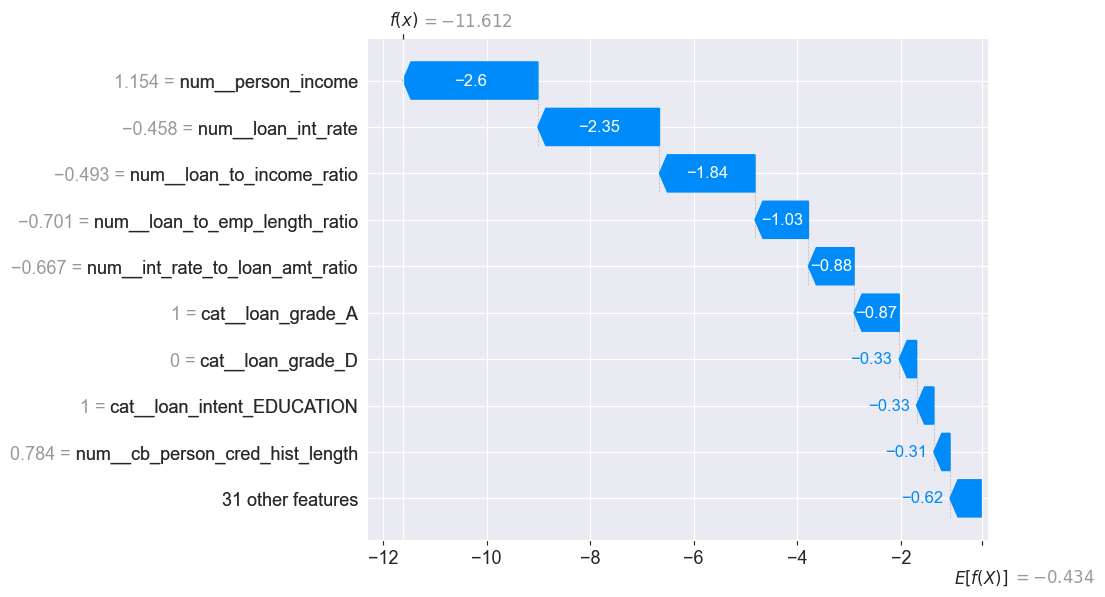

In [132]:
shap.plots.waterfall(shap_vis[0])

In [80]:
model_path = Path(project_root, "scoring_models", "xgboost_risk_model.json")

In [81]:
model_weighted.save_model(model_path)
print("XGBoost model saved: ", model_path)

XGBoost model saved:  C:\Users\Selim\Desktop\PythonProjects\ai-credit-underwriting-platform\data\xgboost_risk_model.json


In [84]:
joblib.dump(preprocess, Path(project_root, "scoring_models", "preprocessor.pkl"))
print("Preprocessor saved.")

Preprocessor saved.
